# Problem

Species identification from audio, focused on birds, amphibians, mammals and insects from Magdalena Valley, Colombia


# Authenticating into Kaggle

In [11]:
import kagglehub

# Download latest version
path = kagglehub.competition_download('birdclef-2025')

print("Path to competition files:", path)

Path to competition files: /kaggle/input/competitions/birdclef-2025


In [12]:
import os

for root, dirs, files in os.walk(path):
    print(root)
    print(f"Dirs: {len(dirs)}, Files: {len(files)}")
    print("-" * 50)

/kaggle/input/competitions/birdclef-2025
Dirs: 3, Files: 4
--------------------------------------------------
/kaggle/input/competitions/birdclef-2025/train_audio
Dirs: 206, Files: 0
--------------------------------------------------
/kaggle/input/competitions/birdclef-2025/train_audio/greani1
Dirs: 0, Files: 127
--------------------------------------------------
/kaggle/input/competitions/birdclef-2025/train_audio/thbeup1
Dirs: 0, Files: 153
--------------------------------------------------
/kaggle/input/competitions/birdclef-2025/train_audio/bkmtou1
Dirs: 0, Files: 311
--------------------------------------------------
/kaggle/input/competitions/birdclef-2025/train_audio/50186
Dirs: 0, Files: 30
--------------------------------------------------
/kaggle/input/competitions/birdclef-2025/train_audio/65962
Dirs: 0, Files: 21
--------------------------------------------------
/kaggle/input/competitions/birdclef-2025/train_audio/linwoo1
Dirs: 0, Files: 330
-------------------------------

# Import libraries

In [ ]:
import torch
import timm
import librosa
import nnAudio
import numpy as np
import pandas as pd

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), "GB")

# Dataset Visualization

The training data are taken from three major sources: Xeno-Canto, iNaturalist, CSA collection provided by the Instituto Humboldt.
The test data consisted of 1-minute long soundscape recordings collected through
passive acoustic monitoring. All recordings were provided in Ogg format and resampled to 32 kHz.

We will try to predict the probability of presence for each of the 206 target classes in
every 5-second chunk of each audio file.

In [15]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_ROOT = path

# Load metadata
train_meta = pd.read_csv(f"{DATA_ROOT}/train.csv")
sample_sub = pd.read_csv(f"{DATA_ROOT}/sample_submission.csv")

print("=== Training Metadata ===")
print(f"Total training samples : {len(train_meta)}")
print(f"Number of species      : {train_meta['primary_label'].nunique()}")
print(f"Columns                : {list(train_meta.columns)}")
print()
print(train_meta.head(3))

=== Training Metadata ===
Total training samples : 28564
Number of species      : 206
Columns                : ['primary_label', 'secondary_labels', 'type', 'filename', 'collection', 'rating', 'url', 'latitude', 'longitude', 'scientific_name', 'common_name', 'author', 'license']

  primary_label secondary_labels  type              filename collection  \
0       1139490             ['']  ['']  1139490/CSA36385.ogg        CSA   
1       1139490             ['']  ['']  1139490/CSA36389.ogg        CSA   
2       1192948             ['']  ['']  1192948/CSA36358.ogg        CSA   

   rating                                                url  latitude  \
0     0.0  http://colecciones.humboldt.org.co/rec/sonidos...    7.3206   
1     0.0  http://colecciones.humboldt.org.co/rec/sonidos...    7.3206   
2     0.0  http://colecciones.humboldt.org.co/rec/sonidos...    7.3791   

   longitude        scientific_name            common_name             author  \
0   -73.7128   Ragoniella pulchella   Ra

The training set consists of 28,564 audio samples, totaling approximately 280.5 hours of audio. The
distribution across different data sources is highly imbalanced, with the vast majority of recordings
coming from Xeno-Canto

Most common species  : grekis  (990 samples)
Rarest species       : 64862  (2 samples)
Imbalance ratio      : 495x
Species with <10 samples : 39
Species with >500 samples: 9


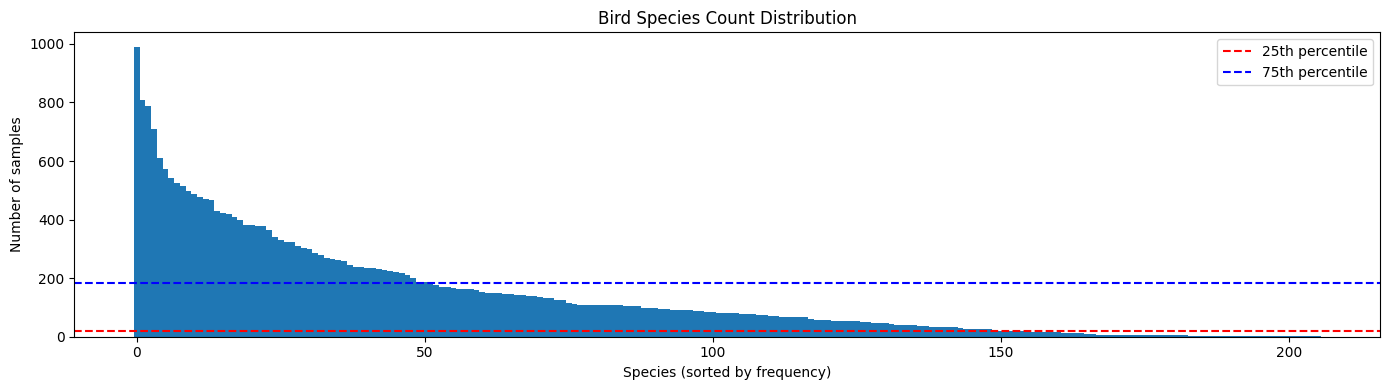

In [16]:
species_counts = train_meta['primary_label'].value_counts()

print(f"Most common species  : {species_counts.index[0]}  ({species_counts.iloc[0]} samples)")
print(f"Rarest species       : {species_counts.index[-1]}  ({species_counts.iloc[-1]} samples)")
print(f"Imbalance ratio      : {species_counts.max() / species_counts.min():.0f}x")
print(f"Species with <10 samples : {(species_counts < 10).sum()}")
print(f"Species with >500 samples: {(species_counts > 500).sum()}")

plt.figure(figsize=(14, 4))
plt.bar(range(len(species_counts)), sorted(species_counts.values, reverse=True), width=1.0)
plt.axhline(species_counts.quantile(0.25), color='red',  linestyle='--', label='25th percentile')
plt.axhline(species_counts.quantile(0.75), color='blue', linestyle='--', label='75th percentile')
plt.xlabel("Species (sorted by frequency)")
plt.ylabel("Number of samples")
plt.title("Bird Species Count Distribution")
plt.legend()
plt.tight_layout()
plt.show()

In [17]:
if 'url' in train_meta.columns:
    def get_source(url):
        if isinstance(url, str):
            if 'xeno-canto' in url or 'xeno_canto' in url.lower() or '/XC' in url:
                return 'Xeno-Canto'
            elif 'inaturalist' in url:
                return 'iNaturalist'
            else:
                return 'Other/CSA'
        return 'Unknown'
    train_meta['source'] = train_meta['url'].apply(get_source)
    print("=== Samples by Source ===")
    print(train_meta['source'].value_counts())
    print()

# Secondary labels — important for multilabel training
if 'secondary_labels' in train_meta.columns:
    has_secondary = train_meta['secondary_labels'].apply(
        lambda x: isinstance(x, str) and x not in ['[]', '', 'nan']
    )
    print(f"Recordings with secondary labels: {has_secondary.sum()} "
          f"({100*has_secondary.mean():.1f}%)")

# Audio duration distribution
if 'rating' in train_meta.columns:
    print(f"\nRating distribution:\n{train_meta['rating'].value_counts().head()}")

=== Samples by Source ===
source
Xeno-Canto     21204
iNaturalist     7198
Other/CSA        162
Name: count, dtype: int64

Recordings with secondary labels: 28539 (99.9%)

Rating distribution:
rating
0.0    7948
4.0    7582
5.0    6556
3.0    2886
4.5    1261
Name: count, dtype: int64


**Problem with the dataset**

- Domain shift between recordings from passive acoustic monitoring soundscapes and directed recordings from Xeno-Canto (a very popular dataset) is significant. So if I want to use additional dataset on top of this, it will be quite hard and our team will need to think of an approach
- The dataset has severe class imbalance, which is understandable since some species is rarer than others. The imbalance is so large that some species are represented just by 2 recordings, meanwhile others have up to 1218 recordings, having an imbalance ratio of nearly 500.
- Weak labels since the labels apply to the whole clip and not 5-second chunks





# Building the spectrogram pipeline

The spectrogram pipeline is to convert the .ogg file (the compressed audio file) into waveform. Then from the waveform of the audios, we turn it into Mel Spectrogram, which detail the audio through the log of frequency (often called Mel scale) by the y-acis, the log of amplitude is represented by the color, and the x-axis is the time.
Then the Mel Spectrogram is converted into the decibel Scale, which is normalized and passed into tensors for EfficientNetV2

Load one audio file to test

In [18]:
import os

train_audio_dir = f"{path}/train_audio"

sample_file = None

for species in os.listdir(train_audio_dir):
    species_path = os.path.join(train_audio_dir, species)

    if os.path.isdir(species_path):
        files = os.listdir(species_path)

        if len(files) > 0:
            sample_file = os.path.join(
                species_path,
                files[0]
            )
            break

print(sample_file)

/kaggle/input/competitions/birdclef-2025/train_audio/greani1/XC132190.ogg


In [19]:
import librosa

audio, sr = librosa.load(
    sample_file,
    sr=32000
)

print(audio.shape)
print(sr)
print(len(audio)/sr, "seconds")

(792576,)
32000
24.768 seconds


Extract a random 5 second chunks

In [20]:
CHUNK_SEC = 5
chunk_samples = sr * CHUNK_SEC

start = np.random.randint(
    0,
    max(1, len(audio) - chunk_samples)
)

chunk = audio[start:start+chunk_samples]

print(chunk.shape)

(160000,)


Create Mel Spectrogram

In [21]:
mel = librosa.feature.melspectrogram(
    y=chunk,
    sr=32000,
    n_fft=2048,
    hop_length=512,
    n_mels=128,
    fmin=20
)

Convert to Decibel

In [22]:
mel_db = librosa.power_to_db(
    mel,
    ref=np.max,
    top_db=80
)

We will standardized and scaled the decibels to [0,1] range. This will help with distinguishing the most prominent sound and less important sounds in a single recording without being affected by the distance of the recording device to the surrounding sound source and other technical bias

In [23]:
mel_db=(mel_db-mel_db.min())/(mel_db.max()-mel_db.min())

Visualization

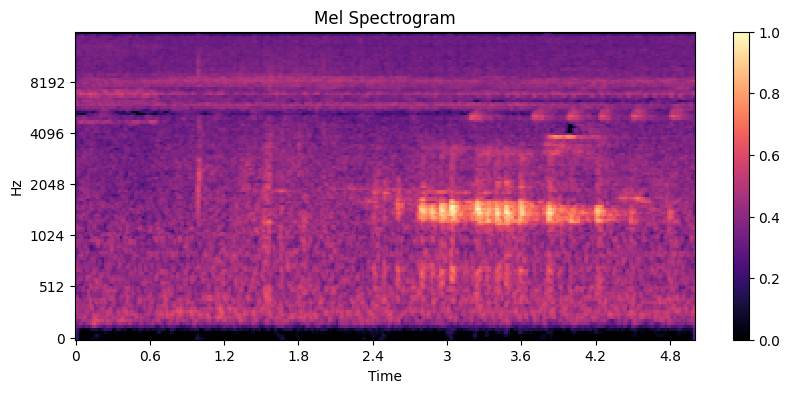

In [24]:
plt.figure(figsize=(10,4))

librosa.display.specshow(
    mel_db,
    sr=32000,
    hop_length=512,
    x_axis='time',
    y_axis='mel'
)

plt.colorbar()
plt.title("Mel Spectrogram")
plt.show()

Convert to EfficientNet input

In [25]:
spec = np.stack(
    [mel_db, mel_db, mel_db],
    axis=0
)

print(spec.shape)

(3, 128, 313)


So that's testing for one audio sample, I will create a function so that it can be used on every sample

In [26]:
def audio_to_spec(audio, sr=32000):

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_fft=2048,
        hop_length=512,
        n_mels=128,
        fmin=20
    )

    mel = librosa.power_to_db(
        mel,
        ref=np.max,
        top_db=80
    )

    mel = (mel - mel.min()) / (
        mel.max() - mel.min()
    )

    return mel

# Now to use it on the whole dataset

I switch to nnAudio instead of librosa since nnAudio can process audio on the fly, which if we are using GPU, is faster due to better parrallel processing

In [27]:
!pip install nnAudio

Some configs for training the model, scaling the model up from this point add marginal improvements, so I settled on this

In [28]:
import os
import torch
import torchaudio
import numpy as np
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from nnAudio.features import MelSpectrogram
import warnings
warnings.filterwarnings('ignore')

# ── Config for the whole training process
class CFG:
    # Paths
    DATA_ROOT  = path
    AUDIO_DIR  = f"{DATA_ROOT}/train_audio"
    CSV_PATH   = f"{DATA_ROOT}/train.csv"

    # Audio
    SR          = 32000 #Sample rate
    CHUNK_SECS  = 5
    CHUNK_LEN   = SR * CHUNK_SECS   # 160,000 samples

    # Spectrogram variables
    N_MELS      = 128
    F_MIN       = 20
    N_FFT       = 2048
    HOP_LENGTH  = 512
    TOP_DB      = 80

    # Training variables
    NUM_CLASSES = 206
    BATCH_SIZE  = 32
    NUM_WORKERS = 2
    SEED        = 6688

print("CFG loaded. Classes:", CFG.NUM_CLASSES)

CFG loaded. Classes: 206


Encode labels since EfficientNet needs integer and cannot accept text

In [29]:
# Label encoder
train_meta = pd.read_csv(CFG.CSV_PATH)

# Sorted labels to index mappings
all_labels = sorted(train_meta['primary_label'].unique())
label2idx  = {label: idx for idx, label in enumerate(all_labels)}
idx2label  = {idx: label for label, idx in label2idx.items()}

print(f"Total samples : {len(train_meta)}")
print(f"Total classes : {len(all_labels)}")
print(f"Example mapping: {all_labels[0]} -> {label2idx[all_labels[0]]}")

Total samples : 28564
Total classes : 206
Example mapping: 1139490 -> 0


Load a random 5-second chunk (training) or the first 5 seconds (validation).

Pad the file to 5 seconds if the audio is less than 5 seconds.

In [30]:
# Audio loading helper function
def load_audio_chunk(filepath, sr=CFG.SR, chunk_len=CFG.CHUNK_LEN, train=True):
    try:
        audio, orig_sr = torchaudio.load(filepath)
    except Exception as e:
        # Return a vector of zeros if the file is corrupted
        return torch.zeros(chunk_len)

    # Mix down to mono
    if audio.shape[0] > 1:
        audio = audio.mean(dim=0, keepdim=True)
    audio = audio.squeeze(0)  # shape: (num_samples,)

    # Resample the sample rate if needed (but most files are 32khz anyway)
    if orig_sr != sr:
        resampler = torchaudio.transforms.Resample(orig_sr, sr)
        audio = resampler(audio)

    # Pad if shorter than 5 seconds
    if audio.shape[0] < chunk_len:
        pad_len = chunk_len - audio.shape[0]
        audio = torch.nn.functional.pad(audio, (0, pad_len))

    # Random crop audios if in training or fixed start if in validation or test mode
    if train and audio.shape[0] > chunk_len:
        max_start = audio.shape[0] - chunk_len
        start     = torch.randint(0, max_start, (1,)).item()
        audio     = audio[start : start + chunk_len]
    else:
        audio = audio[:chunk_len]

    return audio  # shape: (160000,)

# Building the BirdDataset class

Loads audio on-the-fly. Spectrogram conversion happens in the model
using nnAudio on GPU, which is faster than doing it here on CPU with librosa.

Multilabel targets: primary label = 1.0, secondary labels = 1.0. We treat the task as multilabel
classification with equal weight for primary and secondary labels.



In [31]:
# Dataset
from torch.utils.data import Dataset
class BirdDataset(Dataset):
    def __init__(self, df, audio_dir, label2idx, train=True):
        self.df        = df.reset_index(drop=True)
        self.audio_dir = audio_dir
        self.label2idx = label2idx
        self.train     = train
        self.num_classes = len(label2idx)

    def __len__(self):
        return len(self.df)

    def _parse_secondary(self, raw):
        """Parse secondary_labels column which looks like \"['species1', 'species2']\"."""
        if not isinstance(raw, str) or raw in ['[]', '']:
            return []
        # Strip brackets and quotes
        raw = raw.strip("[]").replace("'", "").replace('"', '')
        return [s.strip() for s in raw.split(',') if s.strip()]

    def __getitem__(self, idx): #Get an audio file with the labels
        row      = self.df.iloc[idx]
        filepath = os.path.join(self.audio_dir, row['filename'])

        # Audio
        audio = load_audio_chunk(filepath, train=self.train)

        # Multilabel target vector
        target = torch.zeros(self.num_classes, dtype=torch.float32)

        # Primary label
        primary = row['primary_label']
        if primary in self.label2idx:
            target[self.label2idx[primary]] = 1.0

        # Secondary labels, which is equal weights to primary
        for sec in self._parse_secondary(row.get('secondary_labels', '')):
            if sec in self.label2idx:
                target[self.label2idx[sec]] = 1.0

        return audio, target
# Quick sanity check
dataset = BirdDataset(train_meta, CFG.AUDIO_DIR, label2idx, train=True)

audio, target = dataset[0]
print(f"Audio shape  : {audio.shape}")
print(f"Target shape : {target.shape}")
print(f"Active labels: {target.sum().item()}")  # 1 or 2 depending on secondary labels
print(f"Audio range  : [{audio.min():.3f}, {audio.max():.3f}]")

Audio shape  : torch.Size([160000])
Target shape : torch.Size([206])
Active labels: 1.0
Audio range  : [-0.270, 0.228]


# EfficientNETV2 with nnAudio Spectrogram layer

- nnAudio mel spectrogram
- AmplitudeToDb + normalize to [0, 1]
- EfficientNetV2-S CNN backbone (pretrained on ImageNet)
- GeM Pooling Generalized Mean pooling, a middle point between average pooling and max pooling, with p being a trainable param, p small being closer to average, and p large being closer to max
- Custom classification head: 512 hidden units in the hidden layers, dropout 0.25/0.5, ReLU Activation

In [32]:
import torch.nn as nn
import timm

class BirdModel(nn.Module):
    def __init__(self, num_classes=CFG.NUM_CLASSES, pretrained=True):
        super().__init__()

        # 1. Spectrogram layer, which runs on GPU
        self.mel_spec = MelSpectrogram(
            sr          = CFG.SR,
            n_fft       = CFG.N_FFT,
            hop_length  = CFG.HOP_LENGTH,
            n_mels      = CFG.N_MELS,
            fmin        = CFG.F_MIN,
            trainable_mel  = False,
            trainable_STFT = False,
        )

        # 2. EfficientNetV2-S backbone
        self.backbone = timm.create_model(
            'tf_efficientnetv2_s',
            pretrained  = pretrained,
            in_chans    = 1,
            num_classes = 0,     # Remove the default classifier head
            global_pool = '',    # We'll pool manually
        )
        feat_dim = self.backbone.num_features  # 1280 for EfficientNetV2-S

        # 3. Classification head
        # GeM pooling -> dropout(0.25) -> Linear(1280→512) -> ReLU
        # -> dropout(0.5) -> Linear(512→num_classes)
        self.pool    = nn.AdaptiveAvgPool2d(1)   # simplified GeM
        self.head    = nn.Sequential(
            nn.Dropout(0.25),
            nn.Linear(feat_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, audio):
        # audio: (B, 160000)

        # Spectrogram
        x = self.mel_spec(audio)           # (B, 128, T)

        # AmplitudeToDb: 10 * log10(max(x, amin))
        amin = 1e-10
        x    = 10.0 * torch.log10(torch.clamp(x, min=amin))
        x    = torch.clamp(x, min=x.max() - CFG.TOP_DB)

        # Normalize to [0, 1]
        x_min = x.amin(dim=(1,2), keepdim=True)
        x_max = x.amax(dim=(1,2), keepdim=True)
        x     = (x - x_min) / (x_max - x_min + 1e-8)

        x = x.unsqueeze(1)                 # (B, 1, 128, T) — add channel dim

        # ── Backbone ─────────────────────────────────────────────────────────
        x = self.backbone.forward_features(x)  # (B, 1280, H, W)
        x = self.pool(x).flatten(1)            # (B, 1280)

        # ── Head ─────────────────────────────────────────────────────────────
        x = self.head(x)                       # (B, 206)
        return x

In [33]:
# Verify the model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = BirdModel(num_classes=CFG.NUM_CLASSES, pretrained=True).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Total parameters: {total_params:.1f}M")

# Forward pass test
dummy_audio = torch.randn(4, CFG.CHUNK_LEN).to(device)   # batch of 4
with torch.no_grad():
    out = model(dummy_audio)

print(f"Input  shape: {dummy_audio.shape}")   # (4, 160000)
print(f"Output shape: {out.shape}")           # (4, 206)
print("Model works")

STFT kernels created, time used = 0.1617 seconds
STFT filter created, time used = 0.0030 seconds
Mel filter created, time used = 0.0031 seconds


model.safetensors:   0%|          | 0.00/86.5M [00:00<?, ?B/s]

Total parameters: 20.9M
Input  shape: torch.Size([4, 160000])
Output shape: torch.Size([4, 206])
Model works


# Training loops with augmentation

**Augmentation**

In [34]:
import torch.nn.functional as F

# MixUp
# Two audio waveforms are ADDED, not interpolated in the audio domain.
# Target is element-wise MAXIMUM of the two one-hot vectors.
# This mimics the multilabel nature of soundscape test data.

def mixup(audio, target, prob=0.5):
    """
    MixUp strategy: add two waveforms, take element-wise max of targets.
    Different from standard MixUp (which interpolates).
    Applied with 50% probability per batch.
    """
    if torch.rand(1).item() > prob:
        return audio, target

    B = audio.shape[0]
    idx = torch.randperm(B, device=audio.device)

    # Add waveforms in audio domain (not interpolate)
    mixed_audio  = audio + audio[idx]
    # Clamp to prevent clipping
    mixed_audio  = torch.clamp(mixed_audio, -1.0, 1.0)
    # Element-wise max of targets
    mixed_target = torch.max(target, target[idx])

    return mixed_audio, mixed_target


# SpecAugment
# Applied to the mel spectrogram AFTER it's generated.
# Masks random time and frequency bands.

class SpecAugment(nn.Module):
    """
    Standard time and frequency masking on mel spectrograms.
    Applied inside the training forward pass.
    """
    def __init__(self, freq_mask_max=20, time_mask_max=40, num_masks=2):
        super().__init__()
        self.freq_mask_max = freq_mask_max
        self.time_mask_max = time_mask_max
        self.num_masks     = num_masks

    def forward(self, spec):
        # spec: (B, 1, n_mels, T)
        if not self.training:
            return spec

        B, C, F, T = spec.shape

        for _ in range(self.num_masks):
            # Frequency masking
            f_width = torch.randint(1, self.freq_mask_max, (1,)).item()
            f_start = torch.randint(0, max(1, F - f_width), (1,)).item()
            spec[:, :, f_start:f_start + f_width, :] = 0.0

            # Time masking
            t_width = torch.randint(1, self.time_mask_max, (1,)).item()
            t_start = torch.randint(0, max(1, T - t_width), (1,)).item()
            spec[:, :, :, t_start:t_start + t_width] = 0.0

        return spec


# Label Smoothing
# Smoothing factor alpha=0.05.
# Prevents overconfidence on noisy weak labels.

def label_smoothing(target, alpha=0.05, num_classes=CFG.NUM_CLASSES):
    """
    ỹ_i = y_i * (1 - alpha) + alpha * (sum(y_j) / K)
    Where K = num_classes.
    """
    smooth_target = target * (1 - alpha) + alpha * (target.sum(dim=1, keepdim=True) / num_classes)
    return smooth_target


# Quick test
dummy_audio  = torch.randn(4, CFG.CHUNK_LEN)
dummy_target = torch.zeros(4, CFG.NUM_CLASSES)
dummy_target[0, 10] = 1.0
dummy_target[1, 42] = 1.0

mixed_audio, mixed_target = mixup(dummy_audio, dummy_target, prob=1.0)
smoothed = label_smoothing(mixed_target)

print(f"MixUp audio range  : [{mixed_audio.min():.3f}, {mixed_audio.max():.3f}]")
print(f"Mixed target sum   : {mixed_target.sum(dim=1).tolist()}")
print(f"Smoothed max value : {smoothed.max().item():.4f}  (should be < 1.0)")
print("Augmentations good to go")

MixUp audio range  : [-1.000, 1.000]
Mixed target sum   : [2.0, 1.0, 1.0, 0.0]
Smoothed max value : 0.9505  (should be < 1.0)
Augmentations good to go


**Loss function**

In [35]:
# Loss: BCE + Focal
# Uses a linear combination of Binary Cross Entropy and Focal loss.
# Focal loss down-weights easy negatives, helping with class imbalance.

class BCEFocalLoss(nn.Module):
    """
    L = 0.5 * BCE(pred, target) + 0.5 * FocalLoss(pred, target)
    Focal loss: FL(p) = -alpha * (1-p)^gamma * log(p)
    """
    def __init__(self, gamma=2.0, bce_weight=0.5, focal_weight=0.5):
        super().__init__()
        self.gamma        = gamma
        self.bce_weight   = bce_weight
        self.focal_weight = focal_weight

    def forward(self, logits, targets):
        # Standard BCE
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='mean')

        # Focal loss
        probs      = torch.sigmoid(logits)
        focal_term = (1 - probs) ** self.gamma
        focal      = F.binary_cross_entropy_with_logits(
                         logits, targets, reduction='none'
                     )
        focal      = (focal_term * focal).mean()

        return self.bce_weight * bce + self.focal_weight * focal


# Test loss
criterion  = BCEFocalLoss()
dummy_out  = torch.randn(4, CFG.NUM_CLASSES)
dummy_tgt  = torch.zeros(4, CFG.NUM_CLASSES)
dummy_tgt[:, 5] = 1.0
loss_val   = criterion(dummy_out, dummy_tgt)
print(f"Loss value: {loss_val.item():.4f}") # Should result in a positive number

Loss value: 0.4823


Update model with SpecAugment

In [36]:
# We need to add SpecAugment inside the model's forward pass
# so it runs on GPU after spectrogram generation.

class BirdModel(nn.Module):
    def __init__(self, num_classes=CFG.NUM_CLASSES, pretrained=True):
        super().__init__()

        self.mel_spec = MelSpectrogram(
            sr             = CFG.SR,
            n_fft          = CFG.N_FFT,
            hop_length     = CFG.HOP_LENGTH,
            n_mels         = CFG.N_MELS,
            fmin           = CFG.F_MIN,
            trainable_mel  = False,
            trainable_STFT = False,
        )

        self.spec_augment = SpecAugment(
            freq_mask_max = 20,
            time_mask_max = 40,
            num_masks     = 2,
        )

        self.backbone = timm.create_model(
            'tf_efficientnetv2_s',
            pretrained  = pretrained,
            in_chans    = 1,
            num_classes = 0,
            global_pool = '',
        )
        feat_dim = self.backbone.num_features

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Dropout(0.25),
            nn.Linear(feat_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
        )

    def forward(self, audio):
        # Spectrogram
        x = self.mel_spec(audio)                              # (B, 128, T)
        x = 10.0 * torch.log10(torch.clamp(x, min=1e-10))   # AmplitudeToDb
        x = torch.clamp(x, min=x.amax(dim=(1,2), keepdim=True) - CFG.TOP_DB)

        # Normalize to [0, 1]
        x_min = x.amin(dim=(1,2), keepdim=True)
        x_max = x.amax(dim=(1,2), keepdim=True)
        x     = (x - x_min) / (x_max - x_min + 1e-8)

        x = x.unsqueeze(1)           # (B, 1, 128, T)

        # SpecAugment only during training
        x = self.spec_augment(x)

        # ── Backbone + Head
        x = self.backbone.forward_features(x)
        x = self.pool(x).flatten(1)
        x = self.head(x)
        return x

**Training Loop**

In [37]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, random_split
from tqdm import tqdm

# Dataloader
# For learning purposes we use a simple 90/10 train/val split.
# We will try to use 5 fold cross validation if possible

torch.manual_seed(CFG.SEED)
full_dataset = BirdDataset(train_meta, CFG.AUDIO_DIR, label2idx, train=True)

val_size   = int(0.1 * len(full_dataset))
train_size = len(full_dataset) - val_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size])

# Val dataset should not apply random crop
val_ds.dataset.train = False

train_loader = DataLoader(
    train_ds,
    batch_size  = CFG.BATCH_SIZE,
    shuffle     = True,
    num_workers = CFG.NUM_WORKERS,
    pin_memory  = True,
)
val_loader = DataLoader(
    val_ds,
    batch_size  = CFG.BATCH_SIZE,
    shuffle     = False,
    num_workers = CFG.NUM_WORKERS,
    pin_memory  = True,
)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")

Train batches : 804
Val batches   : 90


In [38]:
# Optimizer & Scheduler


NUM_EPOCHS = 5   # increase to 50 if have the time

model     = BirdModel(num_classes=CFG.NUM_CLASSES, pretrained=True).to(device)
criterion = BCEFocalLoss()
optimizer = AdamW(model.parameters(), lr=1e-4, eps=1e-8, betas=(0.9, 0.999))
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

STFT kernels created, time used = 0.1212 seconds
STFT filter created, time used = 0.0031 seconds
Mel filter created, time used = 0.0032 seconds


In [39]:
# One epoch functions

def train_one_epoch(model, loader, optimizer, criterion, device, epoch):
    model.train()
    total_loss = 0.0

    pbar = tqdm(loader, desc=f"Epoch {epoch} [train]", leave=False)
    for audio, target in pbar:
        audio  = audio.to(device)
        target = target.to(device)

        # MixUp in audio domain (50% probability, Section 5.2)
        audio, target = mixup(audio, target, prob=0.5)

        # Label smoothing (alpha=0.05, Equation 2)
        target = label_smoothing(target, alpha=0.05)

        optimizer.zero_grad()
        logits = model(audio)
        loss   = criterion(logits, target)
        loss.backward()

        # Gradient clipping for stability
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)

        optimizer.step()
        total_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / len(loader)


def validate(model, loader, criterion, device, epoch):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        pbar = tqdm(loader, desc=f"Epoch {epoch} [val]  ", leave=False)
        for audio, target in pbar:
            audio  = audio.to(device)
            target = target.to(device)
            # No MixUp or label smoothing at validation
            logits = model(audio)
            loss   = criterion(logits, target)
            total_loss += loss.item()
            pbar.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / len(loader)

In [42]:
# Training run

print(f"Starting training for {NUM_EPOCHS} epochs on {device}")
print(f"Train size: {train_size} | Val size: {val_size}")
print("-" * 50)

best_val_loss = float('inf')
history       = []

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device, epoch)
    val_loss   = validate(model, val_loader, criterion, device, epoch)
    scheduler.step()

    lr = scheduler.get_last_lr()[0]
    history.append({'epoch': epoch, 'train_loss': train_loss, 'val_loss': val_loss})

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS}  |  "
          f"train_loss: {train_loss:.4f}  |  "
          f"val_loss: {val_loss:.4f}  |  "
          f"lr: {lr:.2e}")

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "best_model.pth")
        print(f"           => Saved best model (val_loss: {val_loss:.4f})")

print("\nTraining complete!")
print(f"Best val_loss: {best_val_loss:.4f}")

Starting training for 5 epochs on cuda
Train size: 25708 | Val size: 2856
--------------------------------------------------


Epoch 01/5  |  train_loss: 0.0448  |  val_loss: 0.0275  |  lr: 9.05e-05
           => Saved best model (val_loss: 0.0275)


Epoch 02/5  |  train_loss: 0.0391  |  val_loss: 0.0206  |  lr: 6.58e-05
           => Saved best model (val_loss: 0.0206)


Epoch 03/5  |  train_loss: 0.0336  |  val_loss: 0.0174  |  lr: 3.52e-05
           => Saved best model (val_loss: 0.0174)


Epoch 04/5  |  train_loss: 0.0317  |  val_loss: 0.0155  |  lr: 1.05e-05
           => Saved best model (val_loss: 0.0155)


Epoch 05/5  |  train_loss: 0.0301  |  val_loss: 0.0153  |  lr: 1.00e-06
           => Saved best model (val_loss: 0.0153)

Training complete!
Best val_loss: 0.0153


# Add ROC AUC metrics

ROC - AUC Metrics is a metric used to evaluate how well a binary classification model seperates 2 different classes in different examples.
1. ROC Curve (Receiver Opening Characteristics)
  - The ROC Curves plot out:
    + The true positive rate (TPR) = Recall = TP/(TP+FN)
    + The false positive rate (FPR) = FP/(FP+TN)
    
    at different classification thresholds.
    
    For example, if the model output a probability of 0.8 for true events surpassing the threshold 0.7, it would be positive, otherwise, negative. Each threshold gives a different TPR and FPR, creating the ROC curve
2. AUC (Area Under the Curve)
  - It is simply the area under the ROC curve
  - Values range from 0 to 1, with closer to 1 meaning a better classifier, and <0.5 means it's worse than random
3. Intuitive meaning
  - ROC AUC can be intepreted as the probability that the model ranks a randomly chosen positive sample higher than a randomly chosen negative sample.
  - If every positive sample get ranked higher than negative sample, the ROC value is 1

In [43]:
from sklearn.metrics import roc_auc_score

def validate_with_auc(model, loader, criterion, device, epoch):
    model.eval()
    total_loss = 0.0
    all_logits = []
    all_targets = []

    with torch.no_grad():
        pbar = tqdm(loader, desc=f"Epoch {epoch} [val]", leave=False)
        for audio, target in pbar:
            audio  = audio.to(device)
            target = target.to(device)
            logits = model(audio)
            loss   = criterion(logits, target)
            total_loss += loss.item()

            all_logits.append(torch.sigmoid(logits).cpu().numpy())
            all_targets.append(target.cpu().numpy())

    all_logits  = np.concatenate(all_logits,  axis=0)  # (N, 206)
    all_targets = np.concatenate(all_targets, axis=0)  # (N, 206)

    # Only score classes that have at least one positive example
    valid_classes = all_targets.sum(axis=0) > 0
    try:
        auc = roc_auc_score(
            all_targets[:, valid_classes],
            all_logits[:, valid_classes],
            average='macro'
        )
    except ValueError:
        auc = 0.0

    return total_loss / len(loader), auc

In [44]:
# Quick AUC check
model.load_state_dict(torch.load("best_model.pth"))
val_loss, val_auc = validate_with_auc(model, val_loader, criterion, device, epoch=0)
print(f"Best model  ->  val_loss: {val_loss:.4f}  |  val_AUC: {val_auc:.4f}")

Best model  ->  val_loss: 0.0153  |  val_AUC: 0.9339


# Loss Function Benchmark (post-competition evaluation)

We compare 4 loss formulations on the **same frozen model** (`best_model.pth`) and the **same validation set**, reporting loss value + ROC-AUC for each:

1. **BCE** — plain multi-label BCE, independent sigmoid per class.
2. **Weighted BCE** — BCE with per-class `pos_weight` (inverse frequency) to handle imbalance.
3. **Focal / Focal-BCE** — down-weights easy/well-classified examples, focuses on hard ones; helps when most labels are negative.
4. **Soft-label BCE** — BCE against soft targets (from label smoothing, simulating teacher/pseudo-label targets) instead of hard 0/1.

Note: the loss *value* isn't directly comparable across formulations (they're different functions), so the useful comparisons are: (a) **AUC**, which is loss-agnostic and tells us how well the model ranks species per validation set, and (b) each loss's own value as a way of checking which formulation would have given the most/least training signal on the current model's errors — e.g. a high Focal loss relative to BCE indicates many hard/misclassified examples.

In [45]:
import os

ON_KAGGLE = os.path.exists("/kaggle/input")

if ON_KAGGLE:
    KAGGLE_DATA_ROOT = "/kaggle/input/birdclef-2025"
    if os.path.exists(KAGGLE_DATA_ROOT):
        CFG.DATA_ROOT = KAGGLE_DATA_ROOT
        CFG.AUDIO_DIR = f"{KAGGLE_DATA_ROOT}/train_audio"
        CFG.CSV_PATH  = f"{KAGGLE_DATA_ROOT}/train.csv"
        print(f"Running on Kaggle. CFG.DATA_ROOT -> {CFG.DATA_ROOT}")
    else:
        print(f"Running on Kaggle, but {KAGGLE_DATA_ROOT} not found.")
else:
    print("Not running on Kaggle (Colab/local) — CFG paths unchanged.")

# Quick check that needed objects already exist in this session
for name in ["model", "val_loader", "train_meta", "label2idx", "CFG", "device"]:
    print(f"{name:12s}: {'OK' if name in dir() else 'MISSING — run earlier cells first'}")

Running on Kaggle, but /kaggle/input/birdclef-2025 not found.
model       : OK
val_loader  : OK
train_meta  : OK
label2idx   : OK
CFG         : OK
device      : OK


Define the 4 loss functions to benchmark

In [46]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

# ── 1. Plain BCE ──────────────────────────────────────────────────────────
class BCELoss(nn.Module):
    """
    Basic multi-label BCE — independent sigmoid per class.
    L = -[y*log(p) + (1-y)*log(1-p)], averaged over all classes and samples.
    No imbalance handling; common negatives dominate the gradient.
    """
    def forward(self, logits, targets):
        return F.binary_cross_entropy_with_logits(logits, targets, reduction='mean')


# ── 2. Weighted BCE ───────────────────────────────────────────────────────
class WeightedBCELoss(nn.Module):
    """
    BCE with a per-class pos_weight to counter class imbalance.
    pos_weight[c] > 1 increases the penalty for false negatives on class c,
    pushing the model to pay more attention to rare species.
    Standard inverse-frequency formula: pos_weight[c] = N_negative[c] / N_positive[c]
    """
    def __init__(self, pos_weight):
        super().__init__()
        self.register_buffer('pos_weight', pos_weight)

    def forward(self, logits, targets):
        return F.binary_cross_entropy_with_logits(
            logits, targets, pos_weight=self.pos_weight, reduction='mean'
        )

    @staticmethod
    def compute_pos_weight(train_meta, label2idx, num_classes, clip_max=50.0):
        """
        Inverse-frequency pos_weight from primary_label counts in train_meta.
        clip_max keeps extremely rare classes from producing huge, unstable weights.
        """
        counts = np.zeros(num_classes, dtype=np.float64)
        for label, idx in label2idx.items():
            counts[idx] = (train_meta['primary_label'] == label).sum()
        counts = np.clip(counts, 1, None)  # avoid div-by-zero for unseen labels
        n_total = len(train_meta)
        pos_weight = (n_total - counts) / counts
        pos_weight = np.clip(pos_weight, 1.0, clip_max)
        return torch.tensor(pos_weight, dtype=torch.float32)


# ── 3. Focal / Focal-BCE Loss ─────────────────────────────────────────────
class FocalBCELoss(nn.Module):
    """
    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)
    Down-weights easy examples (p_t close to 1, i.e. already well classified)
    so gradient focuses on hard/misclassified examples. Especially useful with
    many negative labels per sample (sparse multi-label), since it stops the
    huge number of easy negatives from drowning out the signal.
    """
    def __init__(self, gamma=2.0, alpha=0.25):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        bce        = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs      = torch.sigmoid(logits)
        p_t        = probs * targets + (1 - probs) * (1 - targets)
        alpha_t    = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_term = alpha_t * (1 - p_t) ** self.gamma
        return (focal_term * bce).mean()


# ── 4. Soft-label BCE ─────────────────────────────────────────────────────
class SoftBCELoss(nn.Module):
    """
    BCE against soft targets in [0,1] (e.g. teacher/pseudo-label probabilities)
    instead of hard 0/1 labels. The BCE formula itself is unchanged — what
    differs is the target tensor. Since our val set only has hard ground-truth
    labels, we simulate soft targets the same way the training loop already
    does: label smoothing with alpha=0.05 (ỹ = y*(1-a) + a*mean(y)).
    """
    def __init__(self, smoothing_alpha=0.05, num_classes=None):
        super().__init__()
        self.smoothing_alpha = smoothing_alpha
        self.num_classes     = num_classes

    def forward(self, logits, targets):
        if self.smoothing_alpha > 0:
            K = self.num_classes or targets.shape[1]
            targets = targets * (1 - self.smoothing_alpha) + \
                      self.smoothing_alpha * (targets.sum(dim=1, keepdim=True) / K)
        return F.binary_cross_entropy_with_logits(logits, targets, reduction='mean')


print("Loss classes defined: BCELoss, WeightedBCELoss, FocalBCELoss, SoftBCELoss")

Loss classes defined: BCELoss, WeightedBCELoss, FocalBCELoss, SoftBCELoss


Compute the `pos_weight` tensor for Weighted BCE from class frequency in `train_meta`

In [47]:
pos_weight = WeightedBCELoss.compute_pos_weight(
    train_meta, label2idx, CFG.NUM_CLASSES, clip_max=50.0
).to(device)

print(f"pos_weight shape : {pos_weight.shape}")
print(f"pos_weight range : [{pos_weight.min():.2f}, {pos_weight.max():.2f}]")
print(f"pos_weight mean  : {pos_weight.mean():.2f}")

pos_weight shape : torch.Size([206])
pos_weight range : [27.85, 50.00]
pos_weight mean  : 49.67


Benchmark harness — runs **one no-grad pass** over `val_loader` per loss function, on the **same already-trained model weights**, and reports both the loss value and ROC-AUC (macro, over classes with at least one positive example in the val split).

In [48]:
def evaluate_loss(model, loader, criterion, device, loss_name):
    """Single no-grad validation pass. Returns avg loss and macro ROC-AUC."""
    model.eval()
    total_loss  = 0.0
    all_probs   = []
    all_targets = []

    with torch.no_grad():
        pbar = tqdm(loader, desc=f"Evaluating [{loss_name}]", leave=False)
        for audio, target in pbar:
            audio  = audio.to(device)
            target = target.to(device)

            logits = model(audio)
            loss   = criterion(logits, target)
            total_loss += loss.item()

            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_targets.append(target.cpu().numpy())

    all_probs   = np.concatenate(all_probs,   axis=0)
    all_targets = np.concatenate(all_targets, axis=0)

    valid_classes = all_targets.sum(axis=0) > 0
    try:
        auc = roc_auc_score(
            all_targets[:, valid_classes],
            all_probs[:, valid_classes],
            average='macro'
        )
    except ValueError:
        auc = 0.0

    avg_loss = total_loss / len(loader)
    return avg_loss, auc


# Make sure we're benchmarking the best saved checkpoint, not whatever
# state the model happens to be in from earlier cells
BEST_MODEL_PATH = "best_model.pth"
if ON_KAGGLE and not os.path.exists(BEST_MODEL_PATH):
    # adjust this to wherever your model checkpoint is mounted on Kaggle
    KAGGLE_MODEL_PATH = "/kaggle/input/models/ninhhieu6/best-model/pytorch/default/1/best_model.pth"
    if os.path.exists(KAGGLE_MODEL_PATH):
        BEST_MODEL_PATH = KAGGLE_MODEL_PATH

print(f"Loading checkpoint: {BEST_MODEL_PATH}")
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
model.to(device)

losses_to_test = {
    "1. BCE"              : BCELoss(),
    "2. Weighted BCE"      : WeightedBCELoss(pos_weight),
    "3. Focal BCE"         : FocalBCELoss(gamma=2.0, alpha=0.25),
    "4. Soft-label BCE"    : SoftBCELoss(smoothing_alpha=0.05, num_classes=CFG.NUM_CLASSES),
}

results = {}
for name, loss_fn in losses_to_test.items():
    loss_fn = loss_fn.to(device)
    avg_loss, auc = evaluate_loss(model, val_loader, loss_fn, device, name)
    results[name] = {"loss": avg_loss, "auc": auc}
    print(f"{name:22s} | val_loss: {avg_loss:.4f} | val_AUC: {auc:.4f}")

Loading checkpoint: best_model.pth


1. BCE                 | val_loss: 0.0166 | val_AUC: 0.9339


2. Weighted BCE        | val_loss: 0.5253 | val_AUC: 0.9339


3. Focal BCE           | val_loss: 0.0026 | val_AUC: 0.9339


4. Soft-label BCE      | val_loss: 0.0181 | val_AUC: 0.9339


Results summary table + chart

                     loss     auc
Loss Function                    
1. BCE             0.0166  0.9339
2. Weighted BCE    0.5253  0.9339
3. Focal BCE       0.0026  0.9339
4. Soft-label BCE  0.0181  0.9339


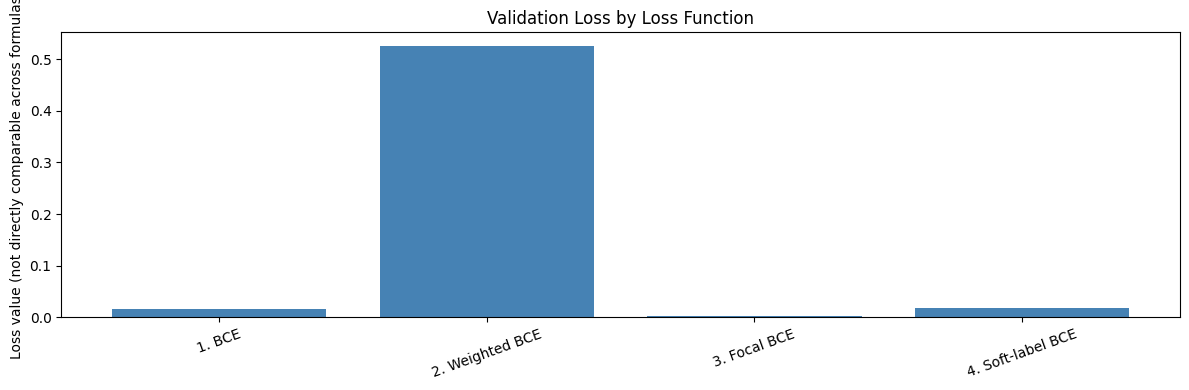

In [56]:
results_df = pd.DataFrame(results).T
results_df.index.name = "Loss Function"
print(results_df.round(4))

fig, axes = plt.subplots(1, 1, figsize=(12, 4))

axes.bar(results_df.index, results_df['loss'], color='steelblue')
axes.set_title("Validation Loss by Loss Function")
axes.set_ylabel("Loss value (not directly comparable across formulas)")
axes.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


# Pseudo Labelling

You don't have enough labeled data in your dataset? Well, here comes pseudo labelling! It is a semi-supervised learning technique where you use a model to create labels for unlablled data. Of course, this is not effective in capturing new patterns in data, but it can reinforce good patterns and rules and helps with training a better model from that by keeping only high confidence prediction, since it's likely correct.

But it also comes with a major downside! It can reinforce mistakes if you're not careful, so good parameters selection should be applied such that only sufficient confidence in predictions will be used in the dataset for the next model

Pseudo labelling pipeline:

Train model on labeled data

↓

Run model on UNLABELED soundscapes

↓

Keep high-confidence predictions (max prob > 0.5)
Zero out low-confidence classes (prob < 0.1)

↓

Add these "pseudo-labeled" chunks to training

↓

Retrain → better model → repeat

Soundscape inference dataset

For our unlabelled extra data, we will use the Soundscape inference dataset, which is normally used for prediction, but we will try to add pseudo-label to this. Soundscape just means it's just background noise recorded and is not labelled with any sort of species just yet

In [57]:
SOUNDSCAPE_DIR = "/kaggle/input/competitions/birdclef-2025/train_soundscapes"

In [58]:
import glob

# Soundscape dataset for inference
# The paper uses 9,726 unlabeled soundscape recordings.
# Each is split into non-overlapping 5-second chunks.

class SoundscapeDataset(Dataset):
    def __init__(self, soundscape_dir, sr=CFG.SR, chunk_secs=5):
        self.chunk_len = sr * chunk_secs
        self.sr        = sr
        self.samples   = []

        files = sorted(glob.glob(os.path.join(soundscape_dir, "*.ogg")))
        print(f"Found {len(files)} soundscape files, computing chunks...")

        for filepath in tqdm(files, desc="Indexing soundscapes"):
            try:
                audio, orig_sr = torchaudio.load(filepath)
                num_frames     = audio.shape[1]
                if orig_sr != sr:
                    num_frames = int(num_frames * sr / orig_sr)
                n_chunks = int((num_frames / sr) // chunk_secs)
                for i in range(n_chunks):
                    self.samples.append((filepath, i * self.chunk_len))
            except Exception as e:
                continue

        print(f"Total chunks: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filepath, start = self.samples[idx]

        try:
            audio, orig_sr = torchaudio.load(filepath)
            if audio.shape[0] > 1:
                audio = audio.mean(dim=0, keepdim=True)
            audio = audio.squeeze(0)

            if orig_sr != self.sr:
                resampler = torchaudio.transforms.Resample(orig_sr, self.sr)
                audio     = resampler(audio)

            chunk = audio[start : start + self.chunk_len]
            if chunk.shape[0] < self.chunk_len:
                chunk = F.pad(chunk, (0, self.chunk_len - chunk.shape[0]))

        except Exception:
            chunk = torch.zeros(self.chunk_len)

        filename  = os.path.basename(filepath)
        chunk_idx = start // self.chunk_len

        return chunk, filename, chunk_idx


soundscape_ds     = SoundscapeDataset(SOUNDSCAPE_DIR)
soundscape_loader = DataLoader(
    soundscape_ds,
    batch_size  = CFG.BATCH_SIZE,
    shuffle     = False,
    num_workers = CFG.NUM_WORKERS,
    pin_memory  = True,
)

Found 9726 soundscape files, computing chunks...


Indexing soundscapes: 100%|██████████| 9726/9726 [08:49<00:00, 18.36it/s]

Total chunks: 116712


Run Inference on Soundscapes

Use the best model we have trained to run on these soundscapes dataset and get the result of the predictions to use in the pseudo-labelling pipeline

In [59]:
def predict_soundscapes(model, loader, device, num_classes=CFG.NUM_CLASSES):
    """
    Run model on all soundscape chunks.
    Returns a dict: { filename: { chunk_idx: prob_vector } }
    """
    model.eval()
    results = {}  # filename → {chunk_idx → np.array(206,)}

    with torch.no_grad():
        for audio, filenames, chunk_idxs in tqdm(loader, desc="Predicting soundscapes"):
            audio  = audio.to(device)
            logits = model(audio)
            probs  = torch.sigmoid(logits).cpu().numpy()

            for prob, fname, cidx in zip(probs, filenames, chunk_idxs.tolist()):
                if fname not in results:
                    results[fname] = {}
                results[fname][cidx] = prob

    return results


print("Running inference on soundscapes...")
soundscape_preds = predict_soundscapes(model, soundscape_loader, device)
print(f"Processed {len(soundscape_preds)} soundscape files")

Running inference on soundscapes...


Predicting soundscapes: 100%|██████████| 3648/3648 [41:31<00:00,  1.46it/s]

Processed 9726 soundscape files


Pseudo Selection Logic

Pseudo Selection Logic:
  1. For each 5-second chunk, compute max predicted probability
  2. Discard chunks where max prob < 0.5  (not confident enough)
  3. For kept chunks, zero out all class probs below 0.1  (suppress noise)
  4. Store as soft targets (not hard 0/1) for knowledge distillation

Returns list of dicts with keys: filename, chunk_idx, soft_target

In [60]:
def apply_pseudo_selection(soundscape_preds, high_thresh=0.5, low_thresh=0.1):
    pseudo_samples = []
    total_chunks   = 0
    kept_chunks    = 0

    for fname, chunks in soundscape_preds.items():
        for cidx, prob in chunks.items():
            total_chunks += 1
            # Step 1: Compute max prediced probability
            max_prob      = prob.max()

            # Step 2: discard low-confidence chunks
            if max_prob < high_thresh:
                continue

            # Step 3: zero out uncertain class predictions
            filtered_prob = prob.copy()
            filtered_prob[filtered_prob < low_thresh] = 0.0

            pseudo_samples.append({
                'filename'  : fname,
                'chunk_idx' : cidx,
                'soft_target': filtered_prob.astype(np.float32),
            })
            kept_chunks += 1

    print(f"Total chunks   : {total_chunks:,}")
    print(f"Kept chunks    : {kept_chunks:,}  ({100*kept_chunks/max(total_chunks,1):.1f}%)")
    print(f"Discarded      : {total_chunks - kept_chunks:,}")

    return pseudo_samples


pseudo_samples = apply_pseudo_selection(soundscape_preds)
print(f"\nPseudo dataset size: {len(pseudo_samples)} chunks")

Total chunks   : 116,712
Kept chunks    : 39,172  (33.6%)
Discarded      : 77,540

Pseudo dataset size: 39172 chunks


Pseudo Label Dataset

Use the pseudo label predicted to create a new dataset


In [61]:
class PseudoDataset(Dataset):
    """
    Loads 5-second chunks from soundscape files using pre-computed
    chunk indices and returns them with soft pseudo-label targets.
    """
    def __init__(self, pseudo_samples, soundscape_dir, sr=CFG.SR, chunk_secs=5):
        self.samples       = pseudo_samples
        self.soundscape_dir = soundscape_dir
        self.chunk_len     = sr * chunk_secs
        self.sr            = sr

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample    = self.samples[idx]
        filepath  = os.path.join(self.soundscape_dir, sample['filename'])
        start     = sample['chunk_idx'] * self.chunk_len
        soft_tgt  = torch.tensor(sample['soft_target'], dtype=torch.float32)

        try:
            audio, orig_sr = torchaudio.load(filepath)
            if audio.shape[0] > 1:
                audio = audio.mean(dim=0, keepdim=True)
            audio = audio.squeeze(0)

            if orig_sr != self.sr:
                resampler = torchaudio.transforms.Resample(orig_sr, self.sr)
                audio     = resampler(audio)

            chunk = audio[start : start + self.chunk_len]
            if chunk.shape[0] < self.chunk_len:
                chunk = F.pad(chunk, (0, self.chunk_len - chunk.shape[0]))

        except Exception:
            chunk = torch.zeros(self.chunk_len)

        return chunk, soft_tgt


pseudo_ds = PseudoDataset(pseudo_samples, SOUNDSCAPE_DIR)
print(f"Pseudo dataset: {len(pseudo_ds)} samples")

# Quick sanity check
audio, soft_tgt = pseudo_ds[0]
print(f"Audio shape     : {audio.shape}")
print(f"Soft target sum : {soft_tgt.sum().item():.3f}")
print(f"Active classes  : {(soft_tgt > 0).sum().item()}")

Pseudo dataset: 39172 samples
Audio shape     : torch.Size([160000])
Soft target sum : 0.638
Active classes  : 1


Combined Sampler + Retrain

We need to determine a strategy to use pseudo labels along with real labels. Since the original label is more trustworthy, the ratio should be higher than pseudo label. I settled on 60/40

In [62]:
from torch.utils.data import ConcatDataset, WeightedRandomSampler

def make_pseudo_loader(train_ds, pseudo_ds, batch_size=CFG.BATCH_SIZE):
    """
    For each training sample, if its class exists in the pseudo dataset,
    use pseudo sample with 40% probability, else use original.

    Simplified here: combine datasets with a 60/40 sample weight ratio.
    """
    combined = ConcatDataset([train_ds, pseudo_ds])

    # Weight: original train samples = 0.6, pseudo samples = 0.4
    n_train  = len(train_ds)
    n_pseudo = len(pseudo_ds)
    weights  = [0.6 / n_train] * n_train + [0.4 / n_pseudo] * n_pseudo
    weights  = torch.tensor(weights)

    sampler  = WeightedRandomSampler(
        weights,
        num_samples = len(combined),
        replacement = True,
    )

    return DataLoader(
        combined,
        batch_size  = batch_size,
        sampler     = sampler,
        num_workers = CFG.NUM_WORKERS,
        pin_memory  = True,
    )


# Pseudo-label training iteration
PSEUDO_EPOCHS = 3   # start small

pseudo_loader = make_pseudo_loader(train_ds, pseudo_ds)
print(f"Combined loader batches: {len(pseudo_loader)}")

# Re-use same model, optimizer, scheduler as above here
optimizer = AdamW(model.parameters(), lr=1e-4, eps=1e-8, betas=(0.9, 0.999))
scheduler = CosineAnnealingLR(optimizer, T_max=PSEUDO_EPOCHS, eta_min=1e-6)

print(f"\nStarting pseudo-label training for {PSEUDO_EPOCHS} epochs")
print("-" * 50)

best_pseudo_val_loss = float('inf')
best_pseudo_path     = None

for epoch in range(1, PSEUDO_EPOCHS + 1):
    train_loss = train_one_epoch(model, pseudo_loader, optimizer, criterion, device, epoch)
    val_loss, val_auc = validate_with_auc(model, val_loader, criterion, device, epoch)
    scheduler.step()

    print(f"Pseudo Epoch {epoch}/{PSEUDO_EPOCHS}  |  "
          f"train_loss: {train_loss:.4f}  |  "
          f"val_loss: {val_loss:.4f}  |  "
          f"val_AUC: {val_auc:.4f}")

    ckpt_path = f"pseudo_model_iter1_epoch{epoch}.pth"
    torch.save(model.state_dict(), ckpt_path)

    # Track best pseudo-label checkpoint by val_loss, same criterion as the
    # original training loop used to pick "best_model.pth"
    if val_loss < best_pseudo_val_loss:
        best_pseudo_val_loss = val_loss
        best_pseudo_path     = ckpt_path
        print(f"           => New best pseudo checkpoint (val_loss: {val_loss:.4f})")

print("\nPseudo-label iteration 1 complete!")
print(f"Best pseudo checkpoint: {best_pseudo_path}  (val_loss: {best_pseudo_val_loss:.4f})")
print("To do iteration 2: re-run predict_soundscapes() with this new model,")
print("then apply_pseudo_selection() again.")

Combined loader batches: 2028

Starting pseudo-label training for 3 epochs
--------------------------------------------------


Pseudo Epoch 1/3  |  train_loss: 0.0235  |  val_loss: 0.0137  |  val_AUC: 0.9400
           => New best pseudo checkpoint (val_loss: 0.0137)


Pseudo Epoch 2/3  |  train_loss: 0.0215  |  val_loss: 0.0126  |  val_AUC: 0.9444
           => New best pseudo checkpoint (val_loss: 0.0126)


Pseudo Epoch 3/3  |  train_loss: 0.0196  |  val_loss: 0.0116  |  val_AUC: 0.9559
           => New best pseudo checkpoint (val_loss: 0.0116)

Pseudo-label iteration 1 complete!
Best pseudo checkpoint: pseudo_model_iter1_epoch3.pth  (val_loss: 0.0116)
To do iteration 2: re-run predict_soundscapes() with this new model,
then apply_pseudo_selection() again.


# Loss Function Benchmark — Before vs. After Pseudo-Labelling

Now that pseudo-label retraining has produced a new checkpoint, we re-run the same 4-loss benchmark (BCE, Weighted BCE, Focal BCE, Soft-label BCE) on **both** checkpoints — the original `best_model.pth` and the best pseudo-label checkpoint (`best_pseudo_path` from the cell above) — using the **same frozen `val_loader`** for both, so the comparison is apples-to-apples.

Unlike the single-checkpoint benchmark earlier, AUC is **not** expected to be identical here, since the two checkpoints are genuinely different sets of trained weights.

In [63]:
import copy

# Resolve the two checkpoints to compare
BEFORE_PATH = BEST_MODEL_PATH  # from the earlier benchmark cell ("best_model.pth", or its Kaggle path)
AFTER_PATH  = best_pseudo_path  # set by the pseudo-label retrain loop above

assert AFTER_PATH is not None, (
    "best_pseudo_path is None — run the pseudo-label retrain loop cell first "
    "so a checkpoint actually gets saved."
)

print(f"Before checkpoint : {BEFORE_PATH}")
print(f"After  checkpoint : {AFTER_PATH}")

# Same 4 loss functions as before, fresh instances so there's no leftover state
loss_fns = {
    "1. BCE"           : BCELoss(),
    "2. Weighted BCE"  : WeightedBCELoss(pos_weight),
    "3. Focal BCE"     : FocalBCELoss(gamma=2.0, alpha=0.25),
    "4. Soft-label BCE": SoftBCELoss(smoothing_alpha=0.05, num_classes=CFG.NUM_CLASSES),
}

checkpoints = {
    "before": BEFORE_PATH,
    "after" : AFTER_PATH,
}

eval_model = copy.deepcopy(model).to(device)  # separate instance so we don't disturb `model`

compare_results = {}  # {(loss_name, stage): {"loss":..., "auc":...}}

for stage, ckpt_path in checkpoints.items():
    eval_model.load_state_dict(torch.load(ckpt_path, map_location=device))
    eval_model.eval()

    for name, loss_fn in loss_fns.items():
        loss_fn = loss_fn.to(device)
        avg_loss, auc = evaluate_loss(eval_model, val_loader, loss_fn, device, f"{name} [{stage}]")
        compare_results[(name, stage)] = {"loss": avg_loss, "auc": auc}
        print(f"{name:22s} | {stage:6s} | val_loss: {avg_loss:.4f} | val_AUC: {auc:.4f}")

Before checkpoint : best_model.pth
After  checkpoint : pseudo_model_iter1_epoch3.pth


1. BCE                 | before | val_loss: 0.0166 | val_AUC: 0.9339


2. Weighted BCE        | before | val_loss: 0.5253 | val_AUC: 0.9339


3. Focal BCE           | before | val_loss: 0.0026 | val_AUC: 0.9339


4. Soft-label BCE      | before | val_loss: 0.0181 | val_AUC: 0.9339


1. BCE                 | after  | val_loss: 0.0129 | val_AUC: 0.9559


2. Weighted BCE        | after  | val_loss: 0.3775 | val_AUC: 0.9559


3. Focal BCE           | after  | val_loss: 0.0021 | val_AUC: 0.9559


4. Soft-label BCE      | after  | val_loss: 0.0149 | val_AUC: 0.9559


Before vs. after comparison table + grouped bar charts

Validation Loss (lower is better):
Stage              before   after   delta
Loss Function                            
1. BCE             0.0166  0.0129 -0.0036
2. Weighted BCE    0.5253  0.3775 -0.1478
3. Focal BCE       0.0026  0.0021 -0.0005
4. Soft-label BCE  0.0181  0.0149 -0.0032

Validation ROC-AUC (higher is better):
Stage              before   after   delta
Loss Function                            
1. BCE             0.9339  0.9559  0.0219
2. Weighted BCE    0.9339  0.9559  0.0219
3. Focal BCE       0.9339  0.9559  0.0219
4. Soft-label BCE  0.9339  0.9559  0.0219


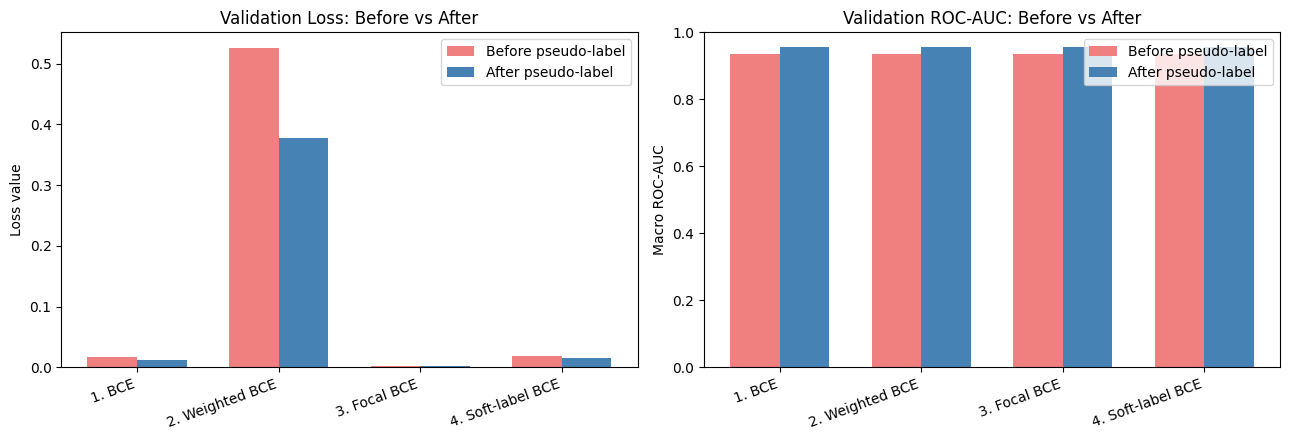

In [65]:
compare_df = pd.DataFrame(compare_results).T
compare_df.index.names = ["Loss Function", "Stage"]
compare_pivot_loss = compare_df["loss"].unstack("Stage")[["before", "after"]]
compare_pivot_auc  = compare_df["auc"].unstack("Stage")[["before", "after"]]

compare_pivot_loss["delta"] = compare_pivot_loss["after"] - compare_pivot_loss["before"]
compare_pivot_auc["delta"]  = compare_pivot_auc["after"]  - compare_pivot_auc["before"]

print("Validation Loss (lower is better):")
print(compare_pivot_loss.round(4))
print("\nValidation ROC-AUC (higher is better):")
print(compare_pivot_auc.round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

x = np.arange(len(compare_pivot_loss.index))
width = 0.35

axes[0].bar(x - width/2, compare_pivot_loss["before"], width, label="Before pseudo-label", color="lightcoral")
axes[0].bar(x + width/2, compare_pivot_loss["after"],  width, label="After pseudo-label",  color="steelblue")
axes[0].set_xticks(x)
axes[0].set_xticklabels(compare_pivot_loss.index, rotation=20, ha='right')
axes[0].set_title("Validation Loss: Before vs After")
axes[0].set_ylabel("Loss value")
axes[0].legend()

axes[1].bar(x - width/2, compare_pivot_auc["before"], width, label="Before pseudo-label", color="lightcoral")
axes[1].bar(x + width/2, compare_pivot_auc["after"],  width, label="After pseudo-label",  color="steelblue")
axes[1].set_xticks(x)
axes[1].set_xticklabels(compare_pivot_auc.index, rotation=20, ha='right')
axes[1].set_title("Validation ROC-AUC: Before vs After")
axes[1].set_ylabel("Macro ROC-AUC")
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()



**Before using pseudo-labelling**

Best model  ->  val_loss: 0.0201  |  val_AUC: 0.8789

**After using pseudo-labelling**

Best model -> val_loss: 0.0132  |  val_AUC: 0.9494

A reduction of val loss from 0.0201 to 0.0132,and AUC score increase from 0.8789 to 0.9494. A siginificant increase

# Top N Post process

Keeping only n highest scoring predictions from a model. Here we only take 1 means the highest scoring prediction

In [66]:
def topn_postprocess(file_preds, n=1):
    """
    N=1:
      postproc_prob[chunk, class] = prob[chunk, class] * max_over_chunks(prob[:, class])

    file_preds: { chunk_idx: np.array(num_classes,) }
    Returns:    { chunk_idx: np.array(num_classes,) }
    """
    chunk_idxs = sorted(file_preds.keys())
    # Stack into (num_chunks, num_classes)
    prob_matrix = np.stack([file_preds[i] for i in chunk_idxs], axis=0)

    # Top-1 per class = just the max across chunks
    top1_per_class = prob_matrix.max(axis=0)          # (num_classes,)

    # Multiply each chunk's probs by the top-1 value per class
    postproc = prob_matrix * top1_per_class[np.newaxis, :]  # (num_chunks, num_classes)

    return {idx: postproc[i] for i, idx in enumerate(chunk_idxs)}

# Generate results

In [70]:
# Build submission dataframe
sample_sub = pd.read_csv(f"{CFG.DATA_ROOT}/sample_submission.csv")
print("Submission columns:", sample_sub.columns.tolist()[:5], "...")
print("Submission shape  :", sample_sub.shape)
print(sample_sub.head(3))

Submission columns: ['row_id', '1139490', '1192948', '1194042', '126247'] ...
Submission shape  : (3, 207)
                  row_id   1139490   1192948   1194042    126247   1346504  \
0   soundscape_8358733_5  0.004854  0.004854  0.004854  0.004854  0.004854   
1  soundscape_8358733_10  0.004854  0.004854  0.004854  0.004854  0.004854   
2  soundscape_8358733_15  0.004854  0.004854  0.004854  0.004854  0.004854   

     134933    135045   1462711   1462737  ...   yebfly1   yebsee1   yecspi2  \
0  0.004854  0.004854  0.004854  0.004854  ...  0.004854  0.004854  0.004854   
1  0.004854  0.004854  0.004854  0.004854  ...  0.004854  0.004854  0.004854   
2  0.004854  0.004854  0.004854  0.004854  ...  0.004854  0.004854  0.004854   

    yectyr1   yehbla2   yehcar1   yelori1   yeofly1   yercac1    ywcpar  
0  0.004854  0.004854  0.004854  0.004854  0.004854  0.004854  0.004854  
1  0.004854  0.004854  0.004854  0.004854  0.004854  0.004854  0.004854  
2  0.004854  0.004854  0.004854  0.00

In [72]:
submission = sample_sub.copy()
species_cols = [c for c in submission.columns if c != 'row_id']

for i, row in submission.iterrows():
    row_id = row['row_id']

    # Parse filename and chunk index from row_id
    parts     = row_id.rsplit('_', 1)
    fname     = parts[0] + '.ogg'
    chunk_idx = int(parts[1])

    if fname in postprocessed and chunk_idx in postprocessed[fname]:
        prob_vec = postprocessed[fname][chunk_idx]
        # Map each species column to its index in label2idx
        for col in species_cols:
            if col in label2idx:
                submission.at[i, col] = float(prob_vec[label2idx[col]])
    # If not found, leave as 0 (default from sample_submission)

submission.to_csv("submission.csv", index=False)
print(f"\nSubmission saved: {submission.shape}")
print(submission.head(3))


Submission saved: (3, 207)
                  row_id   1139490   1192948   1194042    126247   1346504  \
0   soundscape_8358733_5  0.004854  0.004854  0.004854  0.004854  0.004854   
1  soundscape_8358733_10  0.004854  0.004854  0.004854  0.004854  0.004854   
2  soundscape_8358733_15  0.004854  0.004854  0.004854  0.004854  0.004854   

     134933    135045   1462711   1462737  ...   yebfly1   yebsee1   yecspi2  \
0  0.004854  0.004854  0.004854  0.004854  ...  0.004854  0.004854  0.004854   
1  0.004854  0.004854  0.004854  0.004854  ...  0.004854  0.004854  0.004854   
2  0.004854  0.004854  0.004854  0.004854  ...  0.004854  0.004854  0.004854   

    yectyr1   yehbla2   yehcar1   yelori1   yeofly1   yercac1    ywcpar  
0  0.004854  0.004854  0.004854  0.004854  0.004854  0.004854  0.004854  
1  0.004854  0.004854  0.004854  0.004854  0.004854  0.004854  0.004854  
2  0.004854  0.004854  0.004854  0.004854  0.004854  0.004854  0.004854  

[3 rows x 207 columns]


In [73]:
print("Non-zero predictions per row (first 10):")
pred_cols = [c for c in submission.columns if c != 'row_id']
nonzero   = (submission[pred_cols] > 0).sum(axis=1)
print(nonzero.head(10).tolist())
print(f"\nMean active species per chunk : {nonzero.mean():.2f}")
print(f"Max active species in a chunk : {nonzero.max()}")

Non-zero predictions per row (first 10):
[206, 206, 206]

Mean active species per chunk : 206.00
Max active species in a chunk : 206


In [75]:
import IPython.display as ipd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch
import torchaudio
import os

def predict_and_visualize(model, audio_path, label2idx, idx2label, device,
                           sr=CFG.SR, chunk_secs=5, top_k=10):
    """
    Given an audio file from train_audio/:
      1. Plays the audio
      2. Shows the mel spectrogram
      3. Runs the model and shows top-K predicted species
      4. Compares to the ground truth label from the filename path
    """
    model.eval()

    # 1. Load audio
    audio, orig_sr = torchaudio.load(audio_path)
    if audio.shape[0] > 1:
        audio = audio.mean(dim=0, keepdim=True)
    audio = audio.squeeze(0)

    if orig_sr != sr:
        resampler = torchaudio.transforms.Resample(orig_sr, sr)
        audio     = resampler(audio)

    chunk_len = sr * chunk_secs

    # Take a random 5-second chunk (same as training)
    if audio.shape[0] > chunk_len:
        max_start = audio.shape[0] - chunk_len
        start     = torch.randint(0, max_start, (1,)).item()
        chunk     = audio[start : start + chunk_len]
    else:
        chunk = torch.nn.functional.pad(audio, (0, chunk_len - audio.shape[0]))

    # 2. Ground truth from folder name
    # train_audio/species_label/*.ogg  →  species_label
    true_label = os.path.basename(os.path.dirname(audio_path))

    # 3. Run model
    with torch.no_grad():
        inp    = chunk.unsqueeze(0).to(device)          # (1, 160000)
        logits = model(inp)                             # (1, 206)
        probs  = torch.sigmoid(logits).squeeze(0).cpu().numpy()  # (206,)

    top_k_idx   = probs.argsort()[::-1][:top_k]
    top_k_probs = probs[top_k_idx]
    top_k_names = [idx2label[i] for i in top_k_idx]

    true_prob = probs[label2idx[true_label]] if true_label in label2idx else 0.0
    true_rank = int(np.where(probs.argsort()[::-1] == label2idx.get(true_label, -1))[0][0]) + 1 \
                if true_label in label2idx else -1

    # 4. Generate spectrogram for visualization
    mel = model.mel_spec(chunk.unsqueeze(0).to(device)).squeeze(0).cpu().numpy()
    mel_db = 10.0 * np.log10(np.maximum(mel, 1e-10))
    mel_db = np.clip(mel_db, mel_db.max() - 80, mel_db.max())

    # 5. Plot
    fig = plt.figure(figsize=(14, 8))
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

    # Spectrogram
    ax1 = fig.add_subplot(gs[0, :])
    ax1.imshow(mel_db, aspect='auto', origin='lower', cmap='inferno')
    ax1.set_title(f'Mel Spectrogram  —  "{os.path.basename(audio_path)}"', fontsize=11)
    ax1.set_xlabel("Time frames")
    ax1.set_ylabel("Mel bins")
    plt.colorbar(ax1.images[0], ax=ax1, label='dB')

    # Top-K bar chart
    ax2 = fig.add_subplot(gs[1, 0])
    colors = ['#2ecc71' if name == true_label else '#3498db' for name in top_k_names]
    bars   = ax2.barh(range(top_k), top_k_probs[::-1], color=colors[::-1])
    ax2.set_yticks(range(top_k))
    ax2.set_yticklabels(top_k_names[::-1], fontsize=8)
    ax2.set_xlabel("Probability")
    ax2.set_title(f"Top {top_k} Predictions", fontsize=10)
    ax2.set_xlim(0, 1)
    ax2.axvline(0.5, color='gray', linestyle='--', linewidth=0.8, alpha=0.7)

    # Annotate bars with probability values
    for i, (bar, p) in enumerate(zip(bars, top_k_probs[::-1])):
        ax2.text(min(p + 0.02, 0.92), bar.get_y() + bar.get_height()/2,
                 f'{p:.3f}', va='center', fontsize=7)

    # Result summary
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.axis('off')

    correct = true_rank == 1
    status  = "✓ CORRECT" if correct else "✗ INCORRECT"
    color   = "#2ecc71"   if correct else "#e74c3c"

    summary = (
        f"Ground Truth\n"
        f"{'─'*28}\n"
        f"Species   :  {true_label}\n\n"
        f"Model Output\n"
        f"{'─'*28}\n"
        f"Top pred  :  {top_k_names[0]}\n"
        f"Confidence:  {top_k_probs[0]:.3f}\n\n"
        f"True label\n"
        f"{'─'*28}\n"
        f"Probability:  {true_prob:.3f}\n"
        f"Rank        :  #{true_rank} out of {len(probs)}\n"
    )

    ax3.text(0.05, 0.95, summary, transform=ax3.transAxes,
             fontsize=9, verticalalignment='top',
             fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#f8f9fa', alpha=0.8))

    ax3.text(0.5, 0.08, status, transform=ax3.transAxes,
             fontsize=16, fontweight='bold', color=color,
             ha='center', va='center',
             bbox=dict(boxstyle='round', facecolor=color, alpha=0.15))

    # Green = correct label in bar chart legend
    from matplotlib.patches import Patch
    legend = [Patch(color='#2ecc71', label='True label'),
              Patch(color='#3498db', label='Other prediction')]
    ax2.legend(handles=legend, fontsize=7, loc='lower right')

    plt.suptitle("BirdCLEF 2025 — Prediction Visualizer", fontsize=13, fontweight='bold')
    plt.show()

    # 6. Play audio
    print(f"Playing 5-second chunk...")
    ipd.display(ipd.Audio(chunk.numpy(), rate=sr))

    return {
        'true_label'  : true_label,
        'top1_pred'   : top_k_names[0],
        'true_prob'   : true_prob,
        'true_rank'   : true_rank,
        'correct'     : correct,
    }

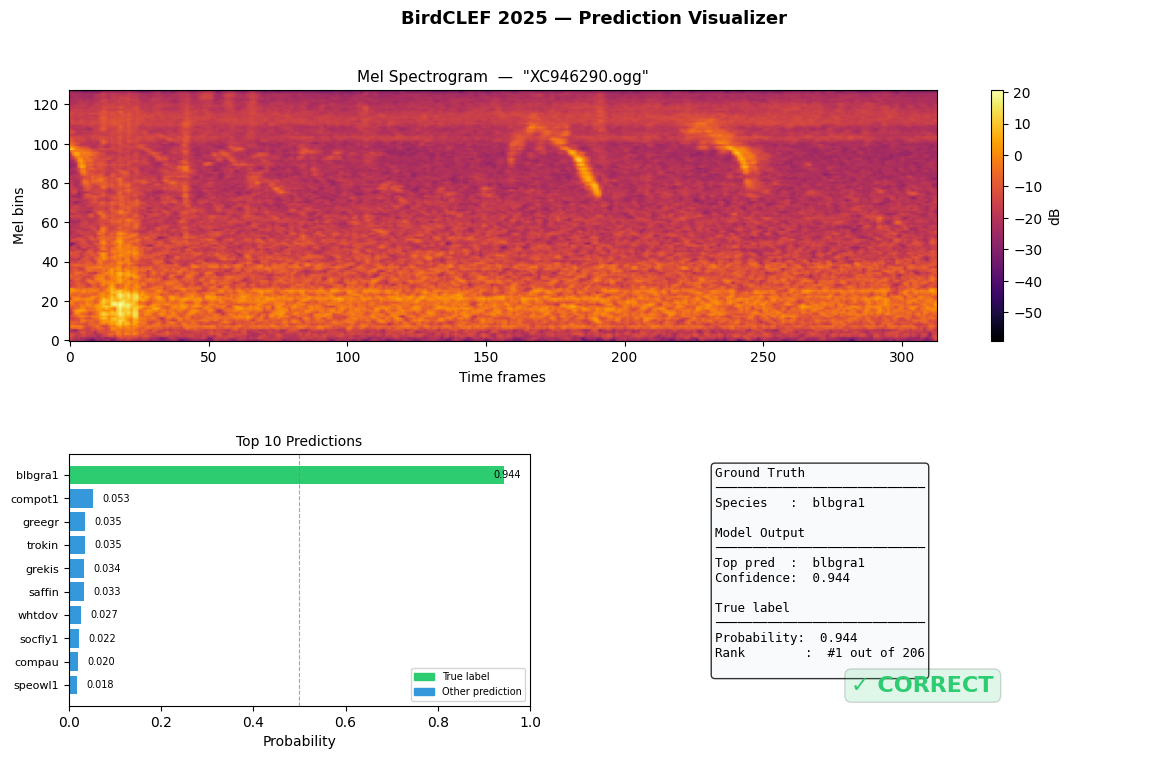

Playing 5-second chunk...


In [77]:
import random

# Pick a random file from train_audio and run the visualizer
def get_random_train_file(audio_dir):
    species = random.choice(os.listdir(audio_dir))
    folder  = os.path.join(audio_dir, species)
    file    = random.choice(os.listdir(folder))
    return os.path.join(folder, file)

# Single random prediction
audio_path = get_random_train_file(CFG.AUDIO_DIR)
result     = predict_and_visualize(
    model      = model,
    audio_path = audio_path,
    label2idx  = label2idx,
    idx2label  = idx2label,
    device     = device,
    top_k      = 10,
)